In [187]:
import pandas as pd 
import seaborn as sns

In [195]:
from utils.plot_missing_rates import plot_snp_missing_rates 

ModuleNotFoundError: No module named 'utils'

# SNP missing information

## Import datasets

In [188]:
! awk -v OFS='\t' '{print $1, $2, $3, $4, $5}' ../scratch/plink/vfaba_raw.lmiss > vfaba_raw.snp.tsv
! head vfaba_raw.snp.tsv

CHR	SNP	N_MISS	N_GENO	F_MISS
chr1S	chr1S_140621	245	248	0.9879
chr1S	chr1S_140640	245	248	0.9879
chr1S	chr1S_140647	245	248	0.9879
chr1S	chr1S_140649	245	248	0.9879
chr1S	chr1S_140691	245	248	0.9879
chr1S	chr1S_140703	245	248	0.9879
chr1S	chr1S_140708	245	248	0.9879
chr1S	chr1S_140714	245	248	0.9879
chr1S	chr1S_140723	246	248	0.9919


In [189]:
# same for filtered SNP
! awk -v OFS='\t' '{print $1, $2, $3, $4, $5}' ../scratch/plink/vfaba_filtered.lmiss > vfaba_filtered.snp.tsv
! head vfaba_filtered.snp.tsv

CHR	SNP	N_MISS	N_GENO	F_MISS
chr1S	chr1S_165485	0	248	0
chr1S	chr1S_165530	0	248	0
chr1S	chr1S_165533	0	248	0
chr1S	chr1S_167677	0	248	0
chr1S	chr1S_167707	0	248	0
chr1S	chr1S_167764	0	248	0
chr1S	chr1S_173981	0	248	0
chr1S	chr1S_174073	0	248	0
chr1S	chr1S_174088	0	248	0


In [190]:
raw = pd.read_csv("./vfaba_raw.snp.tsv", sep="\t")
raw.head()

,CHR,SNP,N_MISS,N_GENO,F_MISS
0,chr1S,chr1S_140621,245,248,0.9879
1,chr1S,chr1S_140640,245,248,0.9879
2,chr1S,chr1S_140647,245,248,0.9879
3,chr1S,chr1S_140649,245,248,0.9879
4,chr1S,chr1S_140691,245,248,0.9879


In [191]:
filtered = pd.read_csv("./vfaba_filtered.snp.tsv", sep="\t")
filtered.head()

,CHR,SNP,N_MISS,N_GENO,F_MISS
0,chr1S,chr1S_165485,0,248,0
1,chr1S,chr1S_165530,0,248,0
2,chr1S,chr1S_165533,0,248,0
3,chr1S,chr1S_167677,0,248,0
4,chr1S,chr1S_167707,0,248,0


## Plot SNP missing rates

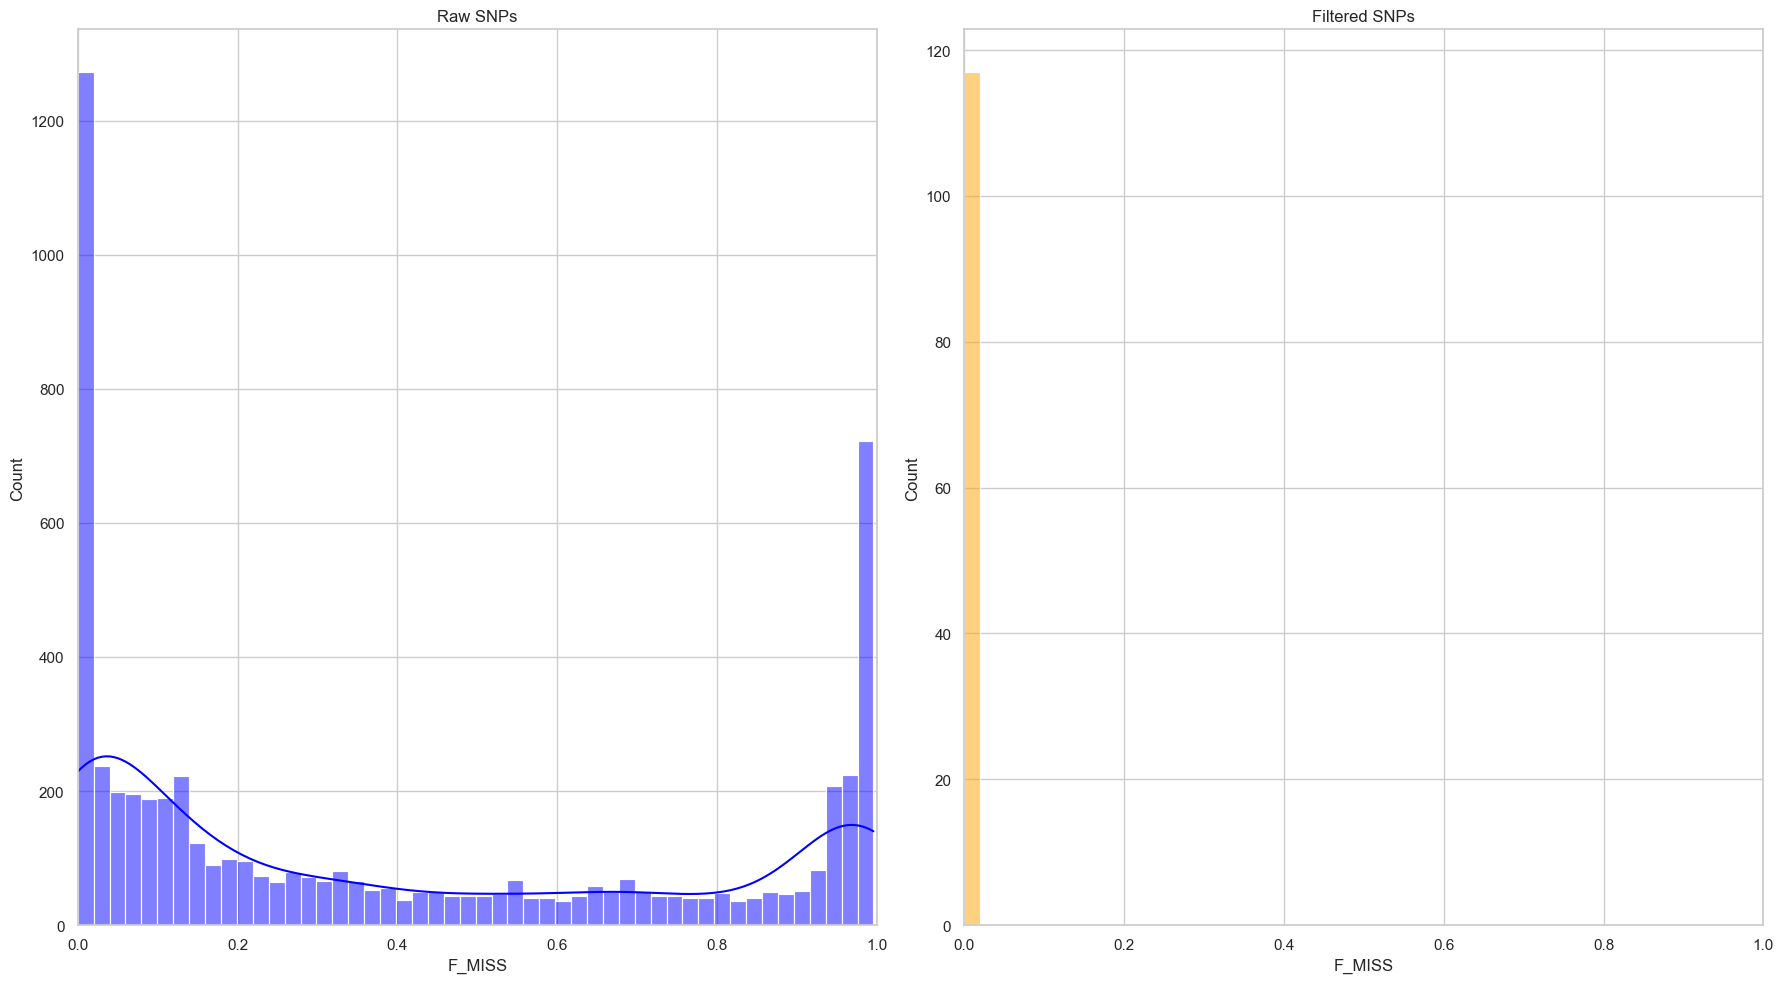

In [ ]:
# Plot the distribution of missing SNPs side by side raw and filtered
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# first plot for raw unfiltered SNPs
sns.histplot(raw['F_MISS'], 
             bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Raw SNPs')
axes[0].set_xlabel('F_MISS')
axes[0].set_xlim(0, 1)

# second plot for filtered SNPs
sns.histplot(filtered['F_MISS'], bins=50, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Filtered SNPs')
axes[1].set_xlabel('F_MISS')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# save
fig.savefig("missing_snps_distribution.png", dpi=300)

# Genotype missing inforation

## Import data

In [193]:
# import genotype missing rates
! awk -v OFS='\t' '{print $2, $3, $4, $5}' ../scratch/plink/vfaba_raw.geno.lmiss > vfaba_raw.geno.lmiss
! awk -v OFS='\t' '{print $2, $3, $4, $5}' ../scratch/plink/vfaba_filtered.geno.lmiss > vfaba_filtered.geno.lmiss


awk: can't open file ../scratch/plink/vfaba_raw.geno.lmiss
 source line number 1
awk: can't open file ../scratch/plink/vfaba_filtered.geno.lmiss
 source line number 1


In [194]:
# import datasets